# Projeto Interdisciplinar — ASA | Entrega 1
## Agente de Monitoramento de Estudantes (Baseline)

**Grupo:** [preencher nomes do grupo]
**Data:** Setembro/2026
**Unidade Curricular:** Inteligência Artificial e Aprendizado de Máquina

Este notebook documenta a construção da baseline (primeira versão) do modelo
preditivo de evasão de estudantes, incluindo análise exploratória, preparação
dos dados, seleção de atributos, treinamento do modelo e explicabilidade
inicial (feature importance).


## 1. Importação de bibliotecas e carga dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report, RocCurveDisplay
)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)


In [2]:
# Bases de dados fornecidas pelo parceiro (ASA/FECAP), já anonimizadas
contato = pd.read_excel('Contato.xlsx')
relacionamentos = pd.read_excel('Relacionamentos.xlsx')
matriculas = pd.read_excel('Matriculas.xlsx')
base_unificada = pd.read_csv('base_unificada_asa-final.csv')

print("Contato:", contato.shape)
print("Relacionamentos:", relacionamentos.shape)
print("Matriculas:", matriculas.shape)
print("Base unificada (já pronta para modelagem):", base_unificada.shape)


Contato: (17812, 7)
Relacionamentos: (96628, 7)
Matriculas: (20920, 11)
Base unificada (já pronta para modelagem): (12842, 24)


## 2. Análise dos Dados

Temos 4 fontes, com granularidades diferentes:

| Fonte | Registros | Granularidade | Conteúdo |
|---|---|---|---|
| `Contato.xlsx` | 17.812 | 1 linha por aluno | Dados demográficos (idade, bairro, cidade, estado civil, sexo) |
| `Relacionamentos.xlsx` | 96.628 | 1 linha por evento/contato | Histórico de interações do aluno com o ASA (motivo do contato, motivo de evasão quando houve) |
| `Matriculas.xlsx` | 20.920 | 1 linha por aluno/matrícula | Situação acadêmica (curso, turno, período, status, risco de evasão já calculado pelo sistema legado) |
| `base_unificada_asa-final.csv` | 12.842 | 1 linha por aluno | Dataset já unificado e com atributos derivados (features de engenharia), pronto para modelagem, com a variável-alvo `evadiu` |

A `base_unificada` é o ponto de partida direto para o treinamento do modelo,
pois já cruza as informações cadastrais, financeiras, acadêmicas e de
relacionamento em uma única linha por estudante.


In [3]:
print("=== Distribuição da variável-alvo (evadiu) ===")
print(base_unificada['evadiu'].value_counts())
print(base_unificada['evadiu'].value_counts(normalize=True).round(3))


=== Distribuição da variável-alvo (evadiu) ===
evadiu
0.0    10330
1.0     2512
Name: count, dtype: int64
evadiu
0.0    0.804
1.0    0.196
Name: proportion, dtype: float64


**Observação:** a base está desbalanceada — aproximadamente **80% não evadiram**
e **20% evadiram**. Isso é esperado (evasão é evento minoritário), mas exige
cuidado na escolha das métricas (acurácia sozinha seria enganosa) e no
treinamento do modelo (usamos `class_weight='balanced'`).


## 3. Preparação dos Dados

### Problemas de qualidade identificados nas bases originais:

- **`Contato.xlsx`**: nulos relevantes em `Estado Civil` (11.411 de 17.812 —
  64%) e `Sexo` (465). Idade, Bairro, Cidade e Estado têm poucos nulos.
- **`Relacionamentos.xlsx`**: `Motivo da Evasão` está nulo em 94.571 das
  96.628 linhas (98%) — faz sentido, pois só é preenchido quando o contato
  foi de fato sobre evasão. Não é um problema de qualidade, é esperado pela
  natureza do dado.
- **`base_unificada_asa-final.csv`** (já processada pelo grupo/parceiro a
  partir das 3 bases brutas): encontramos **7 alunos duplicados** (14 linhas
  com o mesmo `ID_ALUNO`, valores idênticos) e **2 registros com
  `media_notas` acima de 100** (fora da escala esperada de 0–100).

### Tratamento aplicado nesta baseline:
- Duplicados: removidos, mantendo a primeira ocorrência.
- `media_notas` > 100: aplicado *clip* (capping) em 100.
- Variáveis categóricas com "Não informado": mantidas como categoria própria
  (em vez de descartar linhas), pois o "não informar" pode ele mesmo ser um
  sinal relevante de perfil.


In [4]:
# Remover duplicados exatos por ID_ALUNO
df = base_unificada.drop_duplicates(subset='ID_ALUNO', keep='first').reset_index(drop=True)
print(f"Linhas antes: {len(base_unificada)} | depois de remover duplicados: {len(df)}")

# Corrigir outlier de nota fora de escala
print(f"Registros com media_notas > 100 antes: {(df['media_notas'] > 100).sum()}")
df['media_notas'] = df['media_notas'].clip(upper=100)
print(f"Registros com media_notas > 100 depois: {(df['media_notas'] > 100).sum()}")


Linhas antes: 12842 | depois de remover duplicados: 12835
Registros com media_notas > 100 antes: 2
Registros com media_notas > 100 depois: 0


## 4. Seleção de Atributos

Os atributos foram organizados em 4 dimensões, refletindo diferentes
aspectos da vida do estudante que podem sinalizar risco de evasão:

| Dimensão | Atributo | Justificativa |
|---|---|---|
| **Financeira** | `pct_parcelas_em_aberto` | Inadimplência é um dos principais motivos de evasão relatados (ver `Motivo da Evasão`) |
| **Financeira** | `atraso_medio_dias` | Atraso recorrente indica dificuldade financeira mesmo sem inadimplência formal |
| **Financeira** | `tem_bolsa` | Alunos bolsistas têm dinâmica de risco diferente (dependem de manutenção de desempenho) |
| **Financeira** | `valor_total_periodo` | Custo da mensalidade pode pesar na decisão de continuar |
| **Acadêmica** | `media_notas` | Baixo desempenho é fator de desmotivação e risco de reprovação/evasão |
| **Acadêmica** | `media_assiduidade` | Frequência baixa costuma preceder a evasão |
| **Acadêmica** | `pct_reprovacao` | Histórico de reprovações aumenta a chance de desistência |
| **Acadêmica** | `tendencia_notas` / `tendencia_assiduidade` | Direção da mudança (piorando/melhorando) é mais informativa que o valor absoluto isolado |
| **Demográfica** | `Idade`, `Estado Civil`, `Sexo`, `mora_sp_capital` | Perfil sociodemográfico historicamente associado a diferentes taxas de evasão no ensino superior |
| **Acadêmica (perfil)** | `Forma de Ingresso`, `Grau Acadêmico`, `Turno`, `tempo_de_curso`, `total_semestres` | Contexto da trajetória acadêmica do aluno na instituição |
| **Engajamento** | `total_contatos` | Quantidade de vezes que o aluno buscou o ASA pode indicar tanto engajamento quanto insatisfação recorrente |
| **Engajamento** | `dias_desde_ultimo_contato` | Silêncio prolongado pode ser sinal de desengajamento |

Todos esses atributos já vêm pré-computados na `base_unificada`, resultado
de um trabalho anterior de engenharia de atributos sobre as 3 bases brutas.


## 5. Definição das Métricas

**Nesta baseline (Entrega 1):**
- **Acurácia** — visão geral simples, mas insuficiente sozinha dado o
  desbalanceamento de classes.
- **Precisão, Recall e F1-score** — já incluídas nesta primeira versão,
  pois a acurácia isolada seria enganosa (um modelo que sempre prevê
  "não evadiu" já acertaria ~80%).
- **AUC-ROC** — mede a capacidade do modelo de separar as classes
  independente do limiar escolhido.

**Prioridade da métrica:** para este problema, **Recall da classe "evadiu"**
é a métrica mais importante — o custo de não identificar um aluno em risco
(falso negativo) é maior que o custo de sinalizar um aluno que não evadiria
(falso positivo), pois o segundo caso apenas gera um contato preventivo a
mais pela equipe do ASA.

**Para a Entrega 2, pretendemos adicionar:**
- Comparação entre modelos (Regressão Logística vs. Árvore de Decisão vs.
  Random Forest)
- Validação cruzada (k-fold) em vez de um único split treino/teste
- Curva Precision-Recall (mais informativa que ROC em bases desbalanceadas)
- Calibração de probabilidade


## 6. Baseline do Agente de Monitoramento

### 6.1 Score / Modelo Inicial

In [5]:
num_features = [
    'tempo_de_curso', 'Idade', 'mora_sp_capital', 'total_parcelas',
    'pct_parcelas_em_aberto', 'pct_parcelas_acordo', 'atraso_medio_dias',
    'valor_total_periodo', 'media_notas', 'media_assiduidade', 'pct_reprovacao',
    'tendencia_notas', 'tendencia_assiduidade', 'total_semestres',
    'total_contatos', 'dias_desde_ultimo_contato'
]
cat_features = ['Forma de Ingresso', 'Grau Acadêmico', 'Turno', 'Estado Civil', 'Sexo', 'tem_bolsa']

X = df[num_features + cat_features]
y = df['evadiu']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} alunos | Teste: {X_test.shape[0]} alunos")


Treino: 9626 alunos | Teste: 3209 alunos


In [6]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
])

# Regressão Logística: escolhida para a baseline por ser interpretável
# (coeficientes indicam direção e força de cada fator), rápida de treinar
# e um ponto de comparação justo para os modelos mais complexos da Entrega 2.
model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

model.fit(X_train, y_train)
print("Modelo treinado.")


Modelo treinado.


In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Métricas no conjunto de teste ===")
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\n", classification_report(y_test, y_pred, target_names=['Não evadiu', 'Evadiu']))


=== Métricas no conjunto de teste ===
Acurácia:  0.7451
Precisão:  0.4180
Recall:    0.7707
F1-score:  0.5420
AUC-ROC:   0.8200

Matriz de confusão:
[[1907  674]
 [ 144  484]]



               precision    recall  f1-score   support

  Não evadiu       0.93      0.74      0.82      2581
      Evadiu       0.42      0.77      0.54       628

    accuracy                           0.75      3209
   macro avg       0.67      0.75      0.68      3209
weighted avg       0.83      0.75      0.77      3209



**Leitura dos resultados:** o modelo atinge **Recall de ~77%** para a
classe "evadiu" — ou seja, identifica corretamente 3 em cada 4 alunos que
de fato evadiriam. A precisão é mais baixa (~42%), o que é um trade-off
aceitável para uma baseline: preferimos "avisar demais" (falsos positivos,
que geram só um contato preventivo extra) a "avisar de menos" (falsos
negativos, que representam um aluno perdido sem alerta).


### 6.2 Classificação Verde / Amarelo / Vermelho

In [8]:
def classifica_risco(prob):
    if prob < 0.30:
        return 'Verde'
    elif prob < 0.60:
        return 'Amarelo'
    else:
        return 'Vermelho'

resultado = pd.DataFrame({'evadiu_real': y_test.values, 'probabilidade': y_proba})
resultado['categoria_risco'] = resultado['probabilidade'].apply(classifica_risco)

resumo = resultado.groupby('categoria_risco').agg(
    qtd_alunos=('evadiu_real', 'count'),
    taxa_evasao_real=('evadiu_real', 'mean')
).reindex(['Verde', 'Amarelo', 'Vermelho'])
resumo['pct_da_base'] = (resumo['qtd_alunos'] / resumo['qtd_alunos'].sum() * 100).round(1)
resumo['taxa_evasao_real_%'] = (resumo['taxa_evasao_real'] * 100).round(1)
resumo = resumo.drop(columns='taxa_evasao_real')
print(resumo)


                 qtd_alunos  pct_da_base  taxa_evasao_real_%
categoria_risco                                             
Verde                  1384         43.1                 5.8
Amarelo                 994         31.0                12.5
Vermelho                831         25.9                51.0


**Limiares escolhidos:** `< 0.30` → Verde · `0.30 – 0.60` → Amarelo ·
`≥ 0.60` → Vermelho.

Esses cortes foram validados contra a taxa real de evasão dentro de cada
faixa (não são arbitrários): alunos classificados como **Vermelho têm 51%
de chance real de evadir**, contra **12,5% no Amarelo** e apenas **5,8% no
Verde** — uma separação clara e monotônica, que dá confiança na baseline
mesmo sendo a primeira versão.


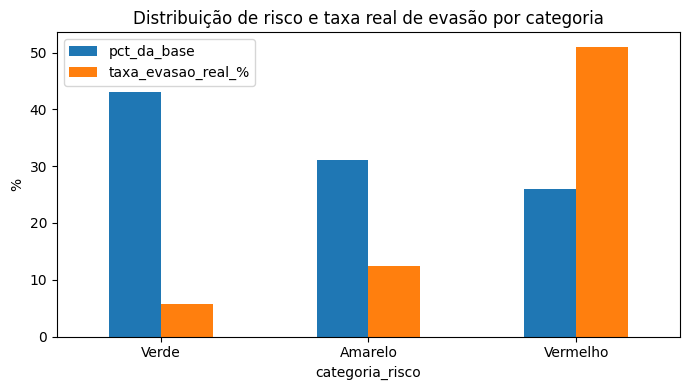

In [9]:
resumo[['pct_da_base','taxa_evasao_real_%']].plot(kind='bar', figsize=(7,4))
plt.title('Distribuição de risco e taxa real de evasão por categoria')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafico_tiers_risco.png', dpi=120)
plt.show()


### 6.3 Explicação dos Fatores

In [10]:
feature_names = (
    num_features +
    list(model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_features))
)
coefs = model.named_steps['clf'].coef_[0]

importancia = pd.DataFrame({'atributo': feature_names, 'coeficiente': coefs})
importancia['abs_coef'] = importancia['coeficiente'].abs()
importancia = importancia.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print("=== Top 10 fatores mais influentes na previsão ===")
print(importancia.head(10)[['atributo', 'coeficiente']].to_string(index=False))


=== Top 10 fatores mais influentes na previsão ===
                           atributo  coeficiente
       Grau Acadêmico_Pós-Graduação    -2.434292
                valor_total_periodo    -2.368206
Forma de Ingresso_Matricula Inicial     1.612756
                     total_parcelas     1.471753
             Forma de Ingresso_Enem     1.315958
       Forma de Ingresso_Vestibular     1.315304
                        media_notas    -1.049039
         Estado Civil_Divorciado(a)    -1.048644
                        Turno_Noite     0.709529
              Grau Acadêmico_Outros    -0.582676


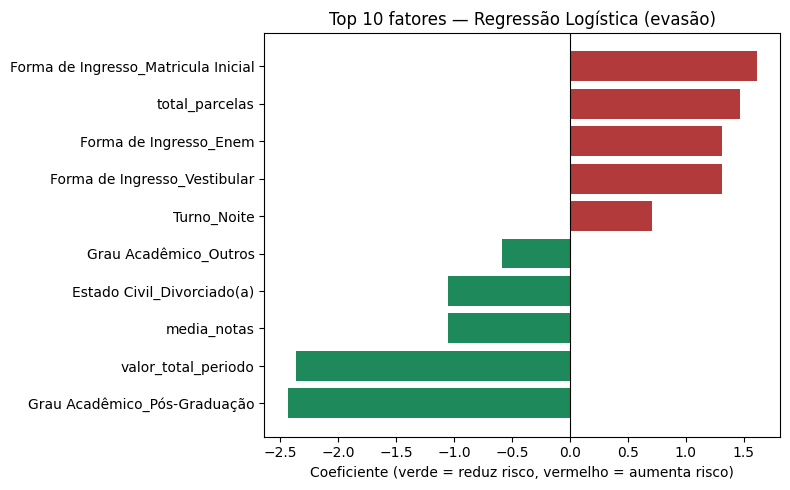

In [11]:
top10 = importancia.head(10).sort_values('coeficiente')
colors = ['#B23A3A' if c > 0 else '#1E8A5B' for c in top10['coeficiente']]
plt.figure(figsize=(8,5))
plt.barh(top10['atributo'], top10['coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 fatores — Regressão Logística (evasão)')
plt.xlabel('Coeficiente (verde = reduz risco, vermelho = aumenta risco)')
plt.tight_layout()
plt.savefig('grafico_feature_importance.png', dpi=120)
plt.show()


**Interpretação:**
- **Fatores que aumentam o risco de evasão** (coeficiente positivo):
  ingresso via ENEM/Vestibular/Matrícula Inicial (vs. transferência, que
  indica um aluno que já tem experiência universitária), maior número de
  parcelas (curso mais longo/caro), turno noturno.
- **Fatores que reduzem o risco de evasão** (coeficiente negativo): cursar
  Pós-Graduação, maior valor total pago no período (associado a maior
  comprometimento financeiro/institucional), e melhor média de notas.

Essa explicação corresponde ao que a equipe do ASA já observa
empiricamente (ex: dificuldade financeira e baixo desempenho como motivos
recorrentes de evasão na base `Relacionamentos.xlsx`), o que é um bom sinal
de que o modelo está capturando padrões reais e não ruído.


## 7. Limitações Conhecidas desta Baseline

- **Classe minoritária pequena em termos absolutos**: apesar de termos
  ~12,8 mil alunos, só ~2,5 mil casos de evasão — para segmentos mais
  específicos (ex: um curso com poucos alunos), o modelo pode ter menos
  confiabilidade.
- **Rótulo `evadiu` sem janela temporal explícita**: não sabemos, a partir
  dos dados fornecidos, se a variável se refere a "evadiu em algum momento
  até a data de extração" — isso precisa ser confirmado com o parceiro
  (ASA) antes da Entrega 2, pois afeta a interpretação temporal do modelo.
- **Baixa precisão (42%)**: o modelo sinaliza bastante aluno que não
  evadiria de fato. Aceitável numa baseline priorizando recall, mas precisa
  ser melhorado com modelos mais robustos e/ou ajuste de limiar.
- **Duplicidade e outliers na base fornecida**: já tratados nesta baseline
  (7 duplicados removidos, 2 outliers de nota corrigidos), mas reforça a
  necessidade de uma etapa de validação de qualidade de dados mais rigorosa
  na próxima entrega.
- **Ausência de validação cruzada**: usamos um único split treino/teste
  (75/25); os números podem variar dependendo da amostra.


## 8. Próximos Passos (Entrega 2)

- Comparar a Regressão Logística com modelos não-lineares (Árvore de
  Decisão, Random Forest, Gradient Boosting), avaliando o trade-off entre
  desempenho e explicabilidade.
- Aplicar validação cruzada (k-fold estratificado) para métricas mais
  robustas.
- Investigar SHAP values para explicabilidade por aluno individual (não só
  agregada).
- Calibrar as probabilidades (Platt scaling / isotonic regression) antes de
  fixar os limiares definitivos de Verde/Amarelo/Vermelho.
- Validar com a equipe do ASA se os limiares e a definição temporal de
  `evadiu` fazem sentido operacional.
- Integrar a saída do modelo com o restante do sistema (dashboard do
  atendente, alertas automáticos).
